# Bike Rental Demand Prediction

## Project ID: PRCP-1018-BikeRental

## Domain: Transportation

This project analyzes a bike-sharing system dataset to understand how environmental, seasonal, and calendar-related factors influence daily bike rental demand.

The dataset contains weather conditions, temporal attributes, and usage information collected over two years, representing daily bike rental activity.

This project focuses on:

- Performing Exploratory Data Analysis (EDA) to identify patterns and trends in bike usage.
- Building and comparing regression models to predict daily bike rental counts.
- Providing data-driven insights to support urban mobility planning and demand management.

The day.csv dataset was chosen as it directly represents daily bike rental demand, which matches the project objective and avoids unnecessary aggregation from hourly data.

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# plot style
sns.set(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

# plot size
plt.rcParams["figure.figsize"] = (8, 5)

# Data Description

In [3]:
df= pd.read_csv('day.csv')
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [4]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
df.drop_duplicates()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [7]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


## Data Cleaning Summary
The dataset consists of daily bike rental records with no missing values. It includes temporal, seasonal, and weather-related features along with the target variable (cnt). Initial inspection shows that most features are numerical, with some representing categorical information encoded as integers. The dataset appears clean and suitable for further analysis and preprocessing.

# Data Preprocessing

In [9]:
# Drop irrelevant column
df.drop(columns=['instant'], inplace=True)

In [10]:
# Convert date column to datetime
df['dteday'] = pd.to_datetime(df['dteday'])

In [11]:
# Drop leakage columns
df.drop(columns=['casual', 'registered'], inplace=True)

In [12]:
categorical_features = [
    'season', 'yr', 'mnth', 'holiday',
    'weekday', 'workingday', 'weathersit'
]
numerical_features = [
    'temp', 'atemp', 'hum', 'windspeed'
]

In [13]:
target = 'cnt'

In [14]:
df.columns

Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

## Data Preprocessing Summary
In this phase, irrelevant and leakage-prone variables were removed to ensure model validity. The date column was converted to a datetime format for temporal analysis. Features were categorized into numerical and categorical variables to enable appropriate preprocessing and encoding in later stages.

# Exploratory Data Analysis 

## Part 1- Univariate Analysis

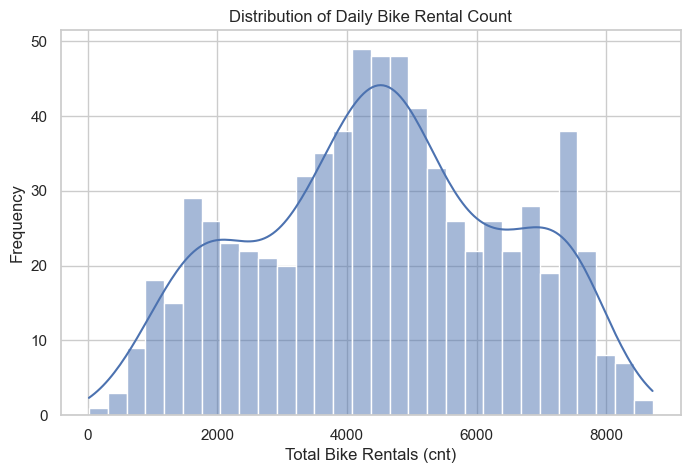

In [15]:
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title('Distribution of Daily Bike Rental Count')
plt.xlabel('Total Bike Rentals (cnt)')
plt.ylabel('Frequency')
plt.show()

The distribution of daily bike rental counts is not heavily skewed and shows a multi-modal pattern. Very low rental values occur infrequently, indicating that days with minimal bike usage are rare. Most observations are concentrated in the moderate range of rentals, forming the primary peak of the distribution. Higher rental values are present but occur less frequently than moderate values. Overall, the demand is fairly well distributed around moderate levels with limited extreme behavior.

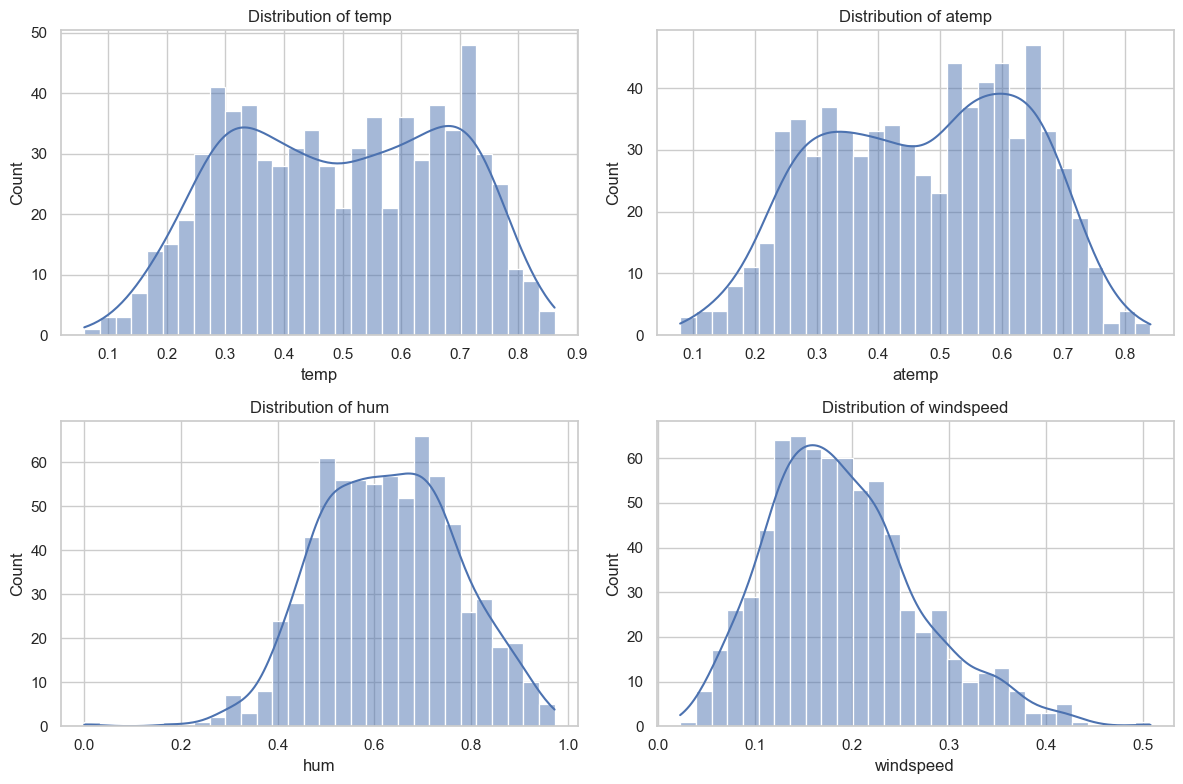

In [16]:
num_features = ['temp', 'atemp', 'hum', 'windspeed']

plt.figure(figsize=(12,8))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

The temperature (temp) and perceived temperature (atemp) distributions exhibit multi-modal patterns, with higher concentrations around lower-moderate and higher-moderate ranges. Extremely low and extremely high temperature values are relatively rare, indicating that most days fall within comfortable temperature conditions. Both features show similar distribution patterns, reflecting their strong relationship.

Humidity (hum) displays a unimodal distribution with most values concentrated in the moderate to high range, suggesting that days with medium to high humidity are more common in the dataset. Very low humidity levels occur infrequently.

Wind speed (windspeed) shows a right-skewed distribution, with a majority of observations concentrated at lower values and fewer days experiencing high wind speeds. This indicates that calm to moderately windy conditions are more prevalent.

Overall, the weather-related features demonstrate meaningful variability while avoiding extreme conditions, making them relevant factors for further analysis of bike rental demand.

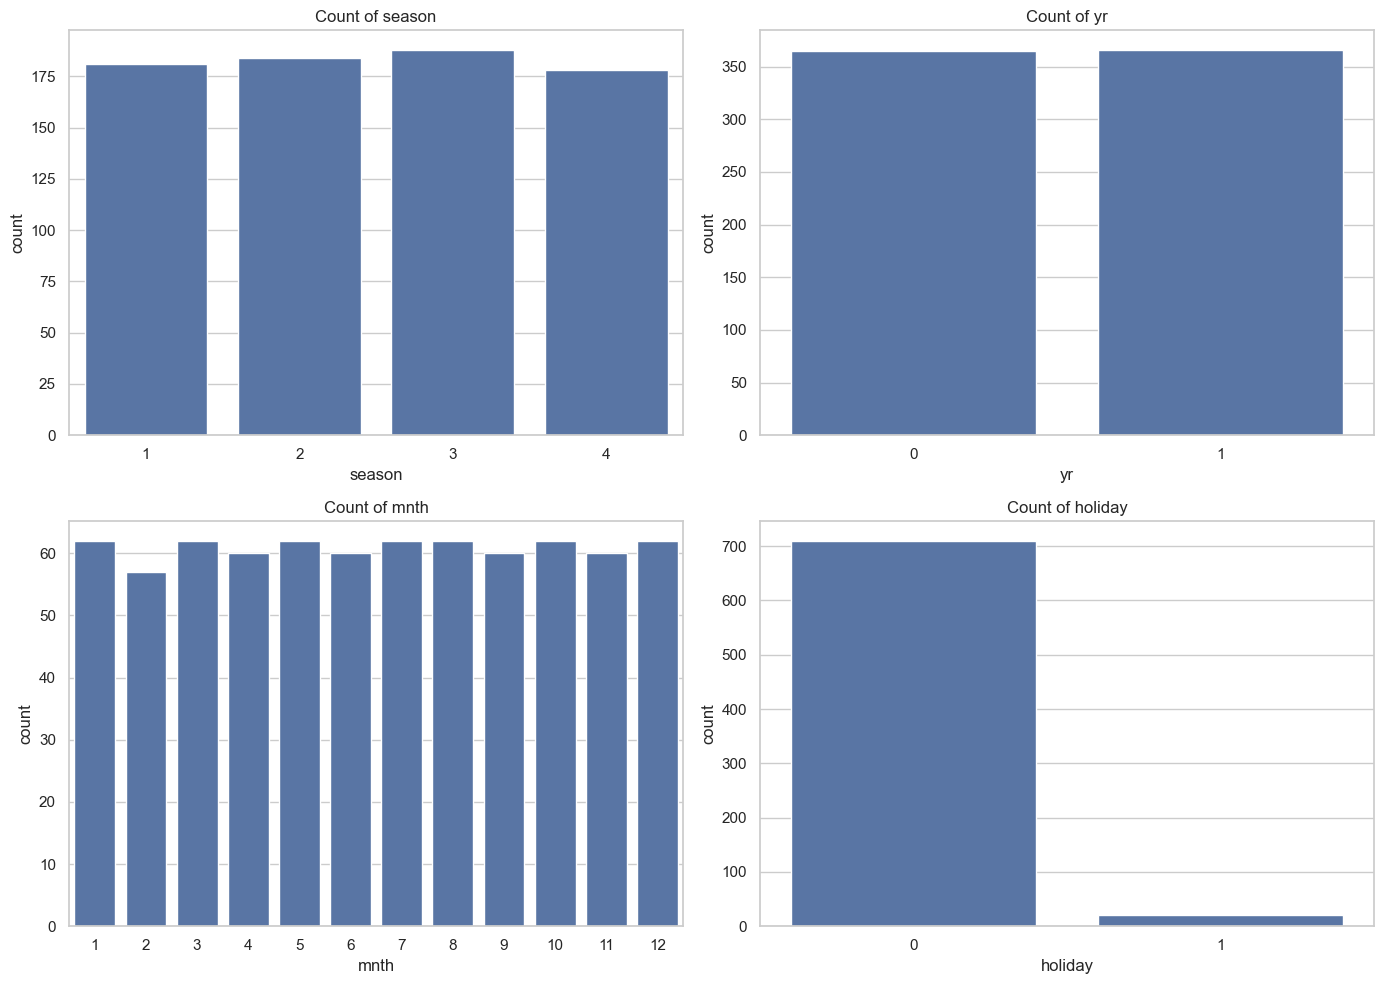

In [17]:
cat_features1 = [
    'season', 'yr', 'mnth', 'holiday'
]

plt.figure(figsize=(14,10))
for i, col in enumerate(cat_features1, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[col])
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

The distribution across seasons appears balanced, indicating that bike rental data is evenly represented throughout the year without seasonal data bias. Similarly, the data is almost equally distributed between the years 2011 and 2012, allowing for meaningful year-wise comparison.

Monthly distribution shows minor variations across months; however, no significant imbalance is observed, suggesting consistent data collection throughout the year. At this stage, no direct inference about demand can be drawn from the monthly distribution alone.

The holiday variable shows a strong imbalance, with non-holiday days significantly outnumbering holidays. This reflects real-world calendar patterns where holidays are infrequent. Despite the imbalance, this feature remains important for further analysis, as holidays may still have a notable impact on bike rental demand.

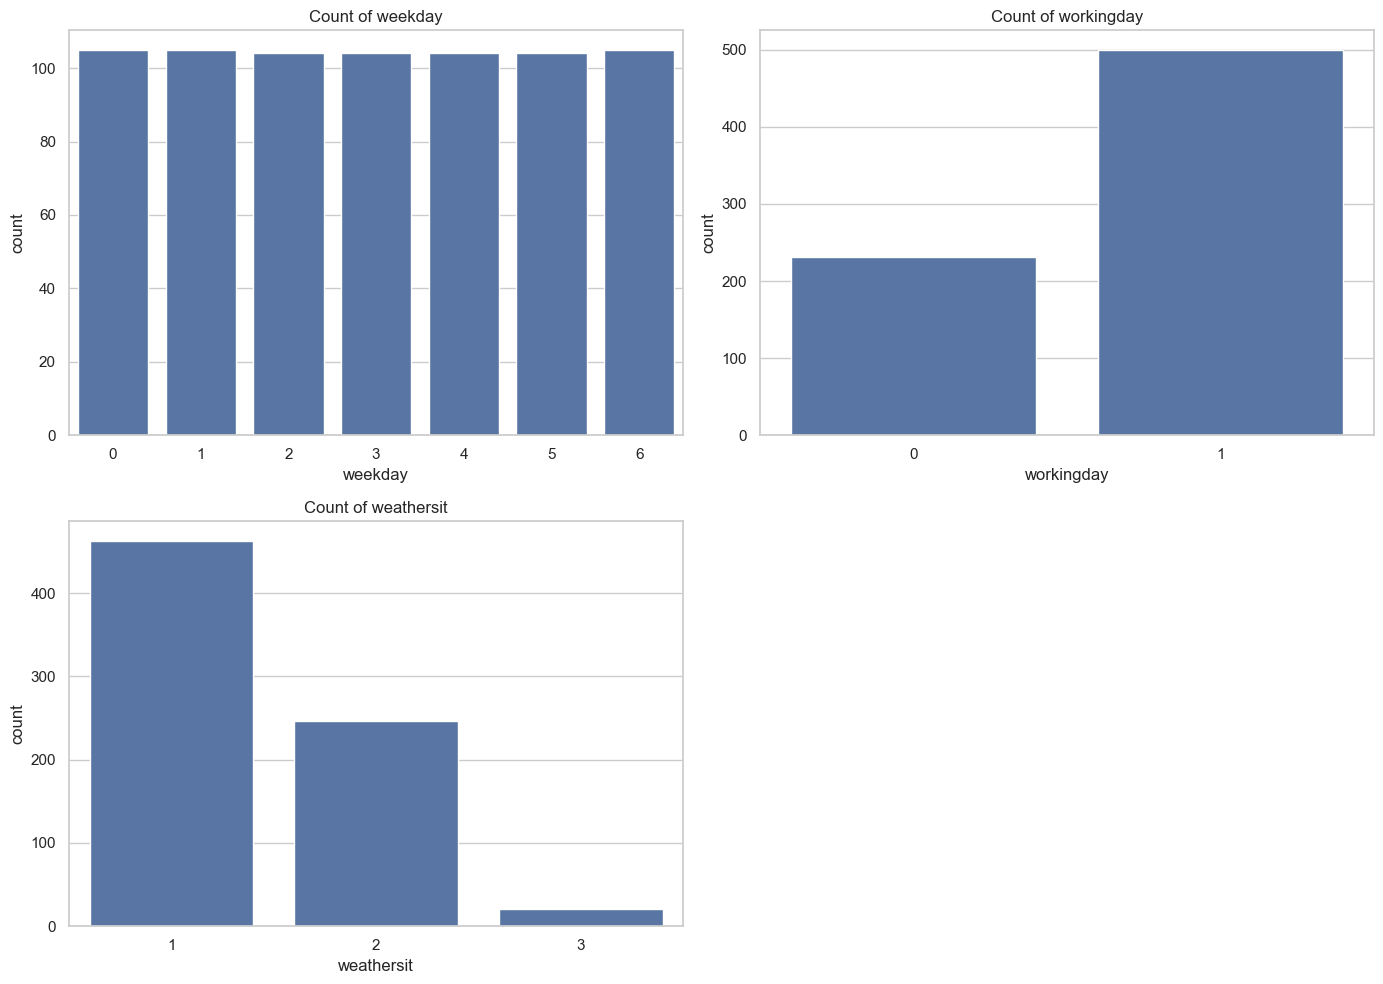

In [18]:
cat_features2 = [
    'weekday', 'workingday', 'weathersit'
]

plt.figure(figsize=(14,10))
for i, col in enumerate(cat_features2, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[col])
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

The distribution across weekdays is fairly balanced, indicating consistent data availability for all days of the week. This ensures that weekday-related analyses are not biased toward specific days.

The workingday variable shows a higher number of working days compared to non-working days, which is expected given typical calendar structures. Despite the imbalance, both categories are well represented and suitable for comparative analysis.

The weather situation variable exhibits a decreasing distribution, where clear or mildly cloudy conditions (category 1) are most frequent, followed by misty or cloudy conditions (category 2), while more severe weather conditions (category 3) occur less often. This reflects realistic weather patterns and provides meaningful variability for further analysis.

## Part 2- Bivariate Analysis

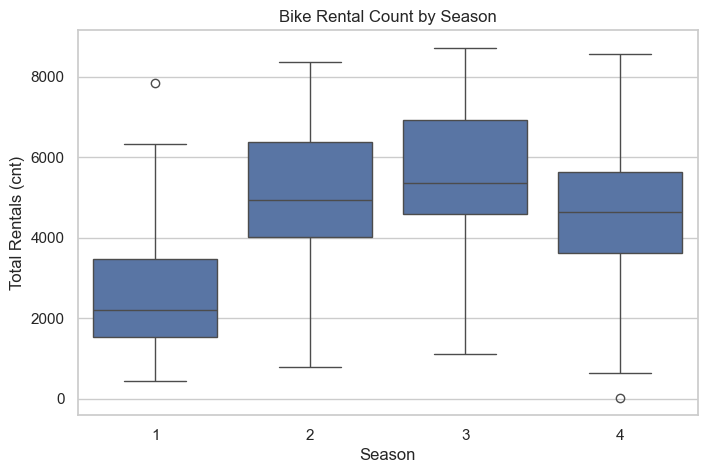

In [19]:
sns.boxplot(x='season', y='cnt', data=df)
plt.title('Bike Rental Count by Season')
plt.xlabel('Season')
plt.ylabel('Total Rentals (cnt)')
plt.show()

The boxplot illustrates a clear seasonal pattern in daily bike rental demand. Winter (Season 1) shows the lowest median rental count with relatively lower variability, indicating reduced bike usage during colder months. Demand increases significantly in Spring (Season 2), reflecting a transition toward more favorable conditions.

Summer (Season 3) records the highest median bike rentals along with the greatest variability, suggesting peak usage during this season. Fall (Season 4) shows a slight decline compared to summer but still maintains higher demand levels than winter and spring. Overall, the analysis highlights seasonality as a strong factor influencing bike rental demand.

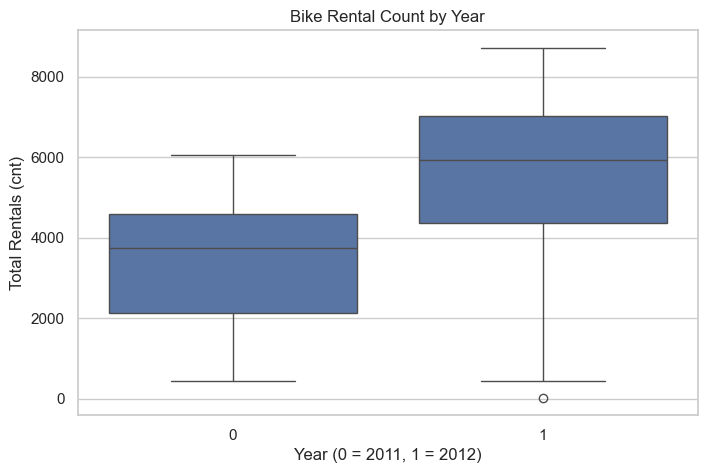

In [20]:
sns.boxplot(x='yr', y='cnt', data=df)
plt.title('Bike Rental Count by Year')
plt.xlabel('Year (0 = 2011, 1 = 2012)')
plt.ylabel('Total Rentals (cnt)')
plt.show()

The boxplot shows a clear increase in daily bike rental demand from 2011 to 2012. The median rental count in 2012 is significantly higher than in 2011, with minimal overlap between the two distributions. This indicates a strong upward trend in bike usage over time, suggesting increased adoption and popularity of the bike-sharing system in 2012 compared to 2011.

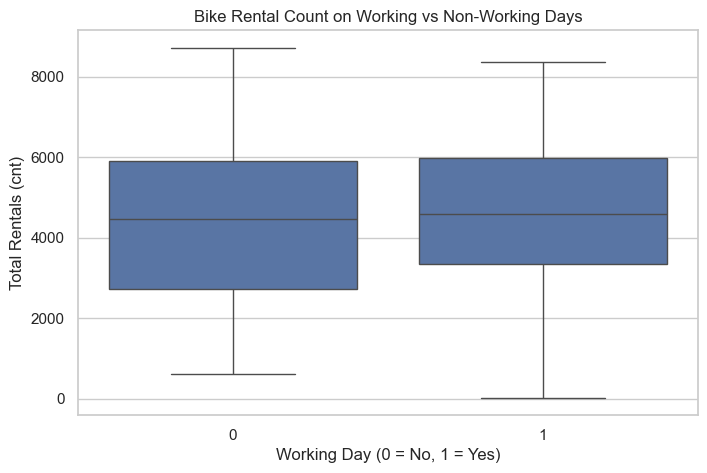

In [21]:
sns.boxplot(x='workingday', y='cnt', data=df)
plt.title('Bike Rental Count on Working vs Non-Working Days')
plt.xlabel('Working Day (0 = No, 1 = Yes)')
plt.ylabel('Total Rentals (cnt)')
plt.show()

The boxplot shows that the median daily bike rental counts for working days and non-working days are very similar, with a high degree of overlap between their distributions. While working days exhibit a slightly higher upper quartile, the overall spread and central tendency remain comparable. This suggests that working day status alone does not strongly differentiate total bike rental demand, indicating consistent usage across both working and non-working days.

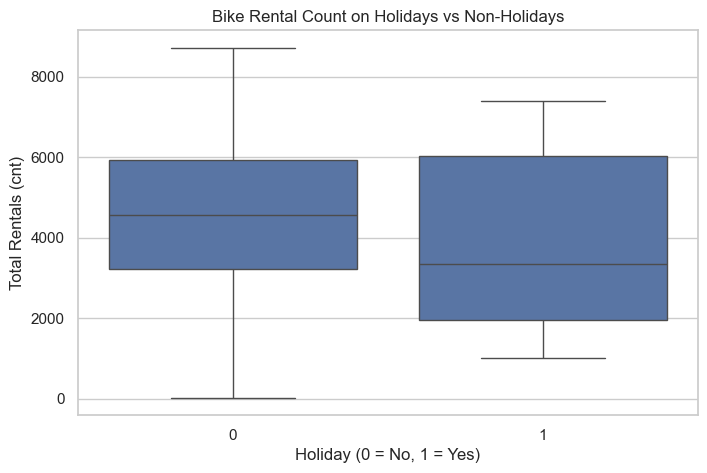

In [22]:
sns.boxplot(x='holiday', y='cnt', data=df)
plt.title('Bike Rental Count on Holidays vs Non-Holidays')
plt.xlabel('Holiday (0 = No, 1 = Yes)')
plt.ylabel('Total Rentals (cnt)')
plt.show()

The boxplot indicates that non-holiday days exhibit a higher median bike rental count compared to holidays. While there is considerable overlap between the two distributions, non-holiday days show a higher lower quartile, suggesting more consistent demand levels. In contrast, holidays display a lower lower quartile, indicating that bike rentals tend to drop more on certain holiday days. Overall, although holidays do not completely eliminate bike usage, non-holiday days are associated with more stable and higher rental demand.

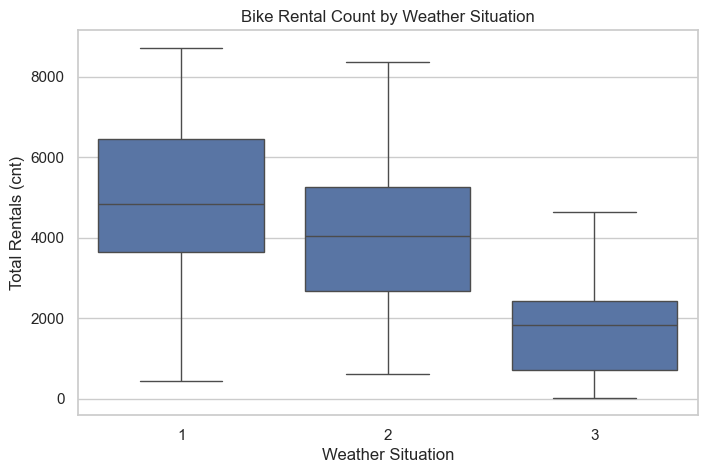

In [23]:
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title('Bike Rental Count by Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Total Rentals (cnt)')
plt.show()

The boxplot reveals a clear decline in bike rental demand as weather conditions worsen. Clear or mildly cloudy weather conditions (weathersit = 1) show the highest median rental counts along with the highest lower and upper quartiles, indicating consistently strong demand. Moderate weather conditions (weathersit = 2) exhibit a lower median with slight overlap with clear conditions, suggesting some reduction in usage. In contrast, adverse weather conditions (weathersit = 3) show the lowest median rental counts with minimal overlap with other categories, highlighting a significant drop in demand during unfavorable weather. Overall, weather conditions emerge as a strong factor influencing daily bike rental demand.

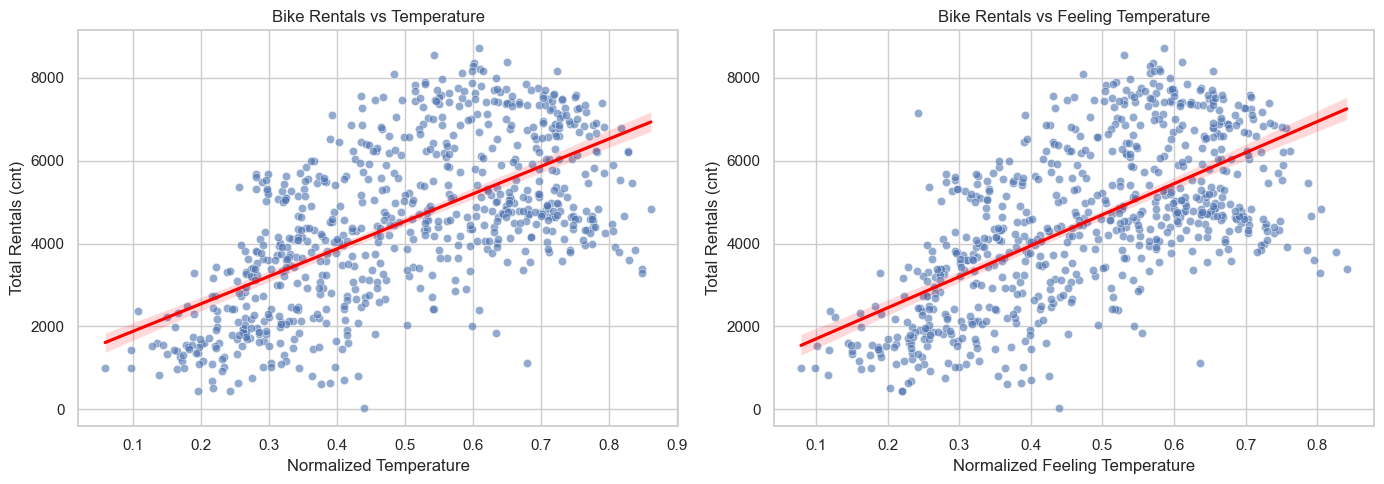

In [24]:
plt.figure(figsize=(14,5))

# Temp vs cnt
plt.subplot(1, 2, 1)
sns.scatterplot(x='temp', y='cnt', data=df, alpha=0.6)
sns.regplot(x='temp', y='cnt', data=df, scatter=False, color='red')
plt.title('Bike Rentals vs Temperature')
plt.xlabel('Normalized Temperature')
plt.ylabel('Total Rentals (cnt)')

# Atemp vs cnt
plt.subplot(1, 2, 2)
sns.scatterplot(x='atemp', y='cnt', data=df, alpha=0.6)
sns.regplot(x='atemp', y='cnt', data=df, scatter=False, color='red')
plt.title('Bike Rentals vs Feeling Temperature')
plt.xlabel('Normalized Feeling Temperature')
plt.ylabel('Total Rentals (cnt)')

plt.tight_layout()
plt.show()


The scatter plots show a clear positive relationship between both actual temperature (`temp`) and perceived temperature (`atemp`) with daily bike rental demand. Bike rentals increase as temperature rises, particularly within moderate temperature ranges. At very low temperatures, rental demand remains low, while at higher temperatures the increase in demand begins to level off, indicating a non-linear relationship.

The similar patterns observed for `temp` and `atemp` suggest that both variables capture comparable information related to thermal comfort. This highlights temperature as a strong influencing factor for bike rental demand while also indicating potential multicollinearity between the two features.

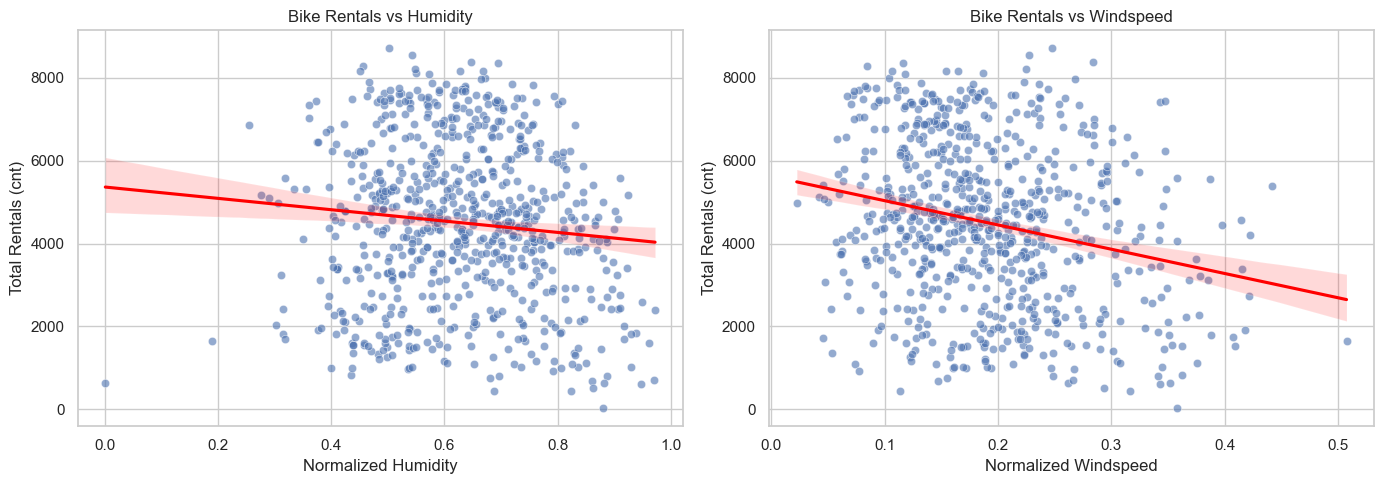

In [25]:
plt.figure(figsize=(14,5))

# Humidity vs cnt
plt.subplot(1, 2, 1)
sns.scatterplot(x='hum', y='cnt', data=df, alpha=0.6)
sns.regplot(x='hum', y='cnt', data=df, scatter=False, color='red')
plt.title('Bike Rentals vs Humidity')
plt.xlabel('Normalized Humidity')
plt.ylabel('Total Rentals (cnt)')

# Windspeed vs cnt
plt.subplot(1, 2, 2)
sns.scatterplot(x='windspeed', y='cnt', data=df, alpha=0.6)
sns.regplot(x='windspeed', y='cnt', data=df, scatter=False, color='red')
plt.title('Bike Rentals vs Windspeed')
plt.xlabel('Normalized Windspeed')
plt.ylabel('Total Rentals (cnt)')

plt.tight_layout()
plt.show()


The scatter plot between humidity and bike rental count shows a generally negative relationship, where higher humidity levels are associated with reduced bike usage. While the relationship is not strictly linear, higher rental counts are more commonly observed at lower to moderate humidity levels.

Similarly, windspeed exhibits a weak to moderate negative relationship with bike rental demand. Most high rental values occur at lower wind speeds, while days with stronger winds tend to show reduced usage. Overall, both humidity and windspeed influence bike rental demand, though their effects appear less pronounced compared to temperature-related features.

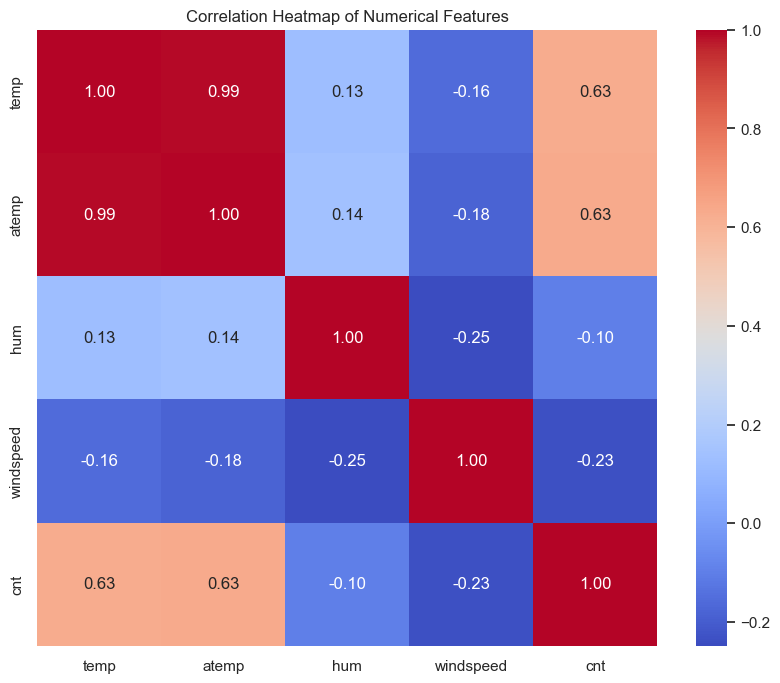

In [26]:
plt.figure(figsize=(10,8))
corr_matrix = df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

The correlation heatmap highlights strong positive relationships between temperature-related variables (`temp`, `atemp`) and daily bike rental demand (`cnt`), confirming that higher temperatures are associated with increased bike usage. Humidity shows a negative correlation with bike rentals, indicating reduced demand under more humid conditions, while windspeed exhibits a weaker negative relationship.

A very high correlation is observed between `temp` and `atemp`, indicating multicollinearity between these features. This suggests that both variables capture similar information related to thermal conditions, and retaining both may not be necessary for certain models. Overall, the correlation analysis supports earlier bivariate observations and provides quantitative evidence for feature selection decisions in subsequent modeling stages.

# Feature Engineering and Selection

In [28]:
df_model = df.drop(columns=['dteday'])

In [29]:
df_model = df_model.drop(columns=['temp'])

In [30]:
X = df_model.drop(columns=['cnt'])
y = df_model['cnt']

In [31]:
categorical_features = [
    'season', 'yr', 'mnth', 'holiday',
    'weekday', 'workingday', 'weathersit'
]

In [32]:
numerical_features = ['atemp', 'hum', 'windspeed']

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

In this phase, the dataset was prepared for machine learning by selecting relevant features and applying appropriate preprocessing techniques. The date column was removed after extracting useful temporal information through derived features. Due to strong multicollinearity between temperature (`temp`) and perceived temperature (`atemp`), only `atemp` was retained based on its behavioral relevance.

Categorical variables were encoded using one-hot encoding to prevent the model from assuming ordinal relationships, while numerical features were retained in their original form. A preprocessing pipeline was created to ensure consistent and leakage-free transformation of data during model training and evaluation.

# Train-Test-Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [37]:
X_test.shape

(147, 10)

# Model Building

In [38]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, random_state=42
    )
}

In [39]:
trained_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

Multiple regression models were trained to predict daily bike rental demand. A pipeline-based approach was used to combine preprocessing and model training, ensuring consistent data transformation and preventing data leakage. Linear models were included as baselines, while tree-based and ensemble models were used to capture non-linear relationships present in the data. This setup enables a fair and systematic comparison of model performance in the evaluation phase.

# Model Evaluation and Comparison

In [41]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model': name,
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

results_df = pd.DataFrame(results)
results_df
results_df.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,RMSE,MAE
5,Gradient Boosting,0.878137,699.039704,493.517336
4,Random Forest,0.864399,737.389283,487.784966
0,Linear Regression,0.845080,788.169675,574.639485
2,Lasso Regression,0.845067,788.201781,574.663229
1,Ridge Regression,0.843358,792.537512,573.158965
3,Decision Tree,0.759514,981.998126,622.632653


Multiple regression models were evaluated using R² score, RMSE, and MAE to assess their predictive performance on unseen test data. Among all models, Gradient Boosting achieved the highest R² score (0.878), indicating strong explanatory power, and the lowest RMSE (699), suggesting the most accurate predictions with fewer large errors.

Random Forest also performed well but showed slightly higher RMSE compared to Gradient Boosting. Linear Regression, Ridge, and Lasso models demonstrated reasonable performance but were limited in capturing non-linear patterns present in the data. The Decision Tree model showed the weakest performance, likely due to overfitting.

Overall, Gradient Boosting Regressor was selected as the best model due to its superior predictive accuracy, robustness, and ability to model complex relationships between environmental and temporal factors and bike rental demand.

# Challenges Faced


One of the primary challenges in this project was the presence of data leakage through the `casual` and `registered` variables, which directly sum to the target variable. These features were removed to ensure valid and unbiased model evaluation.

Another challenge involved multicollinearity between temperature-related features (`temp` and `atemp`). Correlation analysis revealed a strong relationship between these variables, leading to the retention of only `atemp` to reduce redundancy and improve model stability.

The dataset exhibited non-linear relationships between environmental factors and bike rental demand, which posed limitations for linear models. To address this, tree-based and ensemble models were included to better capture complex patterns.

Certain categorical variables such as holidays and working days were naturally imbalanced due to real-world calendar structures. These variables were retained without resampling to preserve realistic demand behavior.

Finally, selecting appropriate evaluation metrics was essential, as classification metrics are unsuitable for regression tasks. RMSE, R², and MAE were chosen to accurately assess predictive performance, with RMSE prioritized due to its sensitivity to large errors.


# Conclusion

This project analyzed daily bike rental demand using environmental, seasonal, and temporal factors. Exploratory data analysis revealed strong seasonal patterns, clear weather dependence, and non-linear relationships between weather variables and bike rental demand. Temperature-related features showed the strongest positive influence, while humidity and adverse weather conditions negatively impacted bike usage.

Multiple regression models were trained and evaluated to predict daily bike rental counts. Among them, the Gradient Boosting Regressor achieved the best overall performance, delivering the highest R² score and the lowest RMSE, making it the most reliable model for demand forecasting. The results demonstrate that machine learning models can effectively capture complex patterns in bike-sharing data and support data-driven decision-making for urban mobility planning.


Future improvements to this project could include incorporating real-time weather forecast data to enhance prediction accuracy. Hourly-level analysis may be explored to capture intraday demand patterns and peak usage hours. Additionally, hyperparameter tuning and cross-validation could be applied to further optimize model performance. Expanding the dataset with more recent data may also help capture evolving user behavior and improve long-term forecasting reliability.
